<a href="https://colab.research.google.com/github/srijitaaa2005/MY-WORKS-DEEP-LEARNING-/blob/main/LENET_5_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten , Dense
from keras.datasets import mnist

In [22]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [23]:
# add channel dimension
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# resize to 32x32
X_train = tf.image.resize(X_train, (32,32))
X_test = tf.image.resize(X_test, (32,32))

print(X_train.shape, X_test.shape)

(60000, 32, 32, 1) (10000, 32, 32, 1)


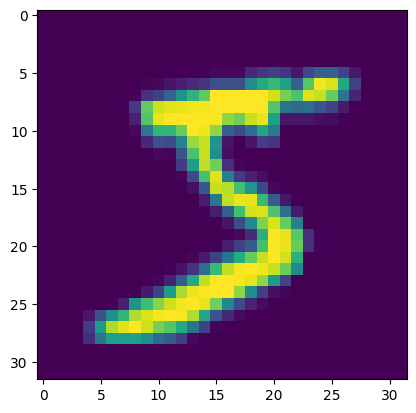

In [24]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])

**LENET ARCHITECHTURE**

In [25]:
model = Sequential()

model.add(Conv2D(kernel_size=(5,5),filters=6,padding='valid',activation='tanh',input_shape=(32,32,1)))
model.add(AveragePooling2D(pool_size=(2,2),strides=(2,2),padding='valid'))

model.add(Conv2D(kernel_size=(5,5),filters=16,padding='valid',activation='tanh'))
model.add(AveragePooling2D(pool_size=(2,2),strides=(2,2),padding='valid'))

model.add(Flatten())

model.add(Dense(120,activation='tanh'))
model.add(Dense(84,activation='tanh'))
model.add(Dense(10,activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_6             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_7             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

model.fit(X_train, y_train, epochs=15, validation_split=0.2)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.9514 - loss: 0.1617 - val_accuracy: 0.9767 - val_loss: 0.0819
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9809 - loss: 0.0625 - val_accuracy: 0.9783 - val_loss: 0.0678
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.9849 - loss: 0.0485 - val_accuracy: 0.9805 - val_loss: 0.0637
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.9885 - loss: 0.0373 - val_accuracy: 0.9842 - val_loss: 0.0539
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 62s 41ms/step - accuracy: 0.9889 - loss: 0.0346 - val_accuracy: 0.9840 - val_loss: 0.0581
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 25ms/step - accuracy: 0.9913 - loss: 0.0275 - val_accuracy: 0.9851 - val_loss: 0.0523
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 24ms/step - accuracy: 0.9918 - loss: 0.0255 - val_accuracy: 0.9831 - val_loss: 0.0621
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 40ms/step - accuracy: 0.9929 -

In [30]:
y_prob= model.predict(X_test)
y_prob

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


array([[1.9858680e-08, 3.1572236e-07, 7.4914253e-09, ..., 9.9999827e-01,
        1.9771301e-08, 8.5411199e-07],
       [7.2047426e-09, 3.9473335e-08, 9.9999934e-01, ..., 2.2592445e-11,
        2.1127384e-08, 9.3890250e-11],
       [8.6049495e-10, 9.9999696e-01, 8.3370422e-09, ..., 2.2407197e-07,
        1.6879509e-06, 3.9403565e-09],
       ...,
       [1.0544529e-10, 2.4372852e-07, 3.3834524e-10, ..., 9.7753298e-07,
        7.5201569e-07, 7.4061319e-07],
       [2.1021713e-09, 1.4572706e-09, 3.9474281e-11, ..., 7.5152345e-10,
        5.0009489e-06, 9.2061497e-11],
       [1.5081679e-07, 1.9768541e-10, 1.1460446e-05, ..., 8.4834556e-11,
        2.1675310e-08, 2.1259053e-10]], dtype=float32)

In [31]:
y_pred=y_prob.argmax(axis=1)
y_pred

array([7, 2, 1, ..., 4, 5, 6])

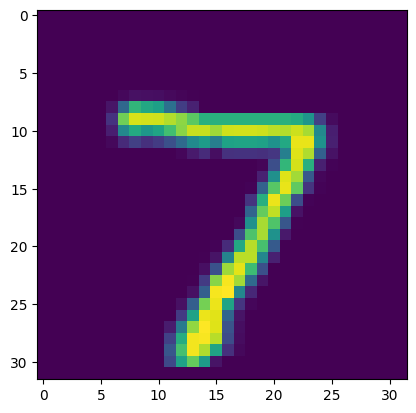

In [32]:
plt.imshow(X_test[0])

In [33]:
model.predict(tf.reshape(X_test[0], (1,32,32,1))).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


array([7])

In [34]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9858